# Notebook 2: ONNX Export & Optimization

This notebook converts the fine-tuned YOLO26n model from PyTorch to ONNX format,
which is required before Hailo DFC can process it.

**Steps:**
1. Load the fine-tuned `best.pt` model
2. Export to ONNX format (opset 11, 640×640 input)
3. Simplify the ONNX graph with onnxsim
4. Inspect graph nodes — identify NMS nodes to strip for Hailo
5. Validate ONNX output with ONNX Runtime
6. Benchmark PyTorch vs ONNX inference speed

**Why strip NMS?** Hailo's compiler cannot efficiently quantize standard PyTorch NMS layers.
Instead, we strip them here and replace with Hailo's hardware-accelerated NMS via an ALLS script
in Notebook 3.

## 1. Setup & Imports

In [3]:
import os
import time
import shutil
import numpy as np
from pathlib import Path

import onnx
from onnxsim import simplify
import onnxruntime as ort
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

WORKSPACE = Path("/home/appuser/Hailo-Training")
MODELS_DIR = WORKSPACE / "models"
DATASET_DIR = WORKSPACE / "datasets" / "doclaynet"

print(f"ONNX version: {onnx.__version__}")
print(f"ONNX Runtime version: {ort.__version__}")
print(f"Models directory: {MODELS_DIR}")

ONNX version: 1.16.0
ONNX Runtime version: 1.18.0
Models directory: /home/appuser/Hailo-Training/models


## 2. Load Fine-Tuned Model

In [4]:
pt_path = MODELS_DIR / "best.pt"
assert pt_path.exists(), f"Model not found at {pt_path}. Run Notebook 1 first."

model = YOLO(str(pt_path))
pt_size_mb = pt_path.stat().st_size / (1024 * 1024)

print(f"Loaded model: {pt_path}")
print(f"PyTorch model size: {pt_size_mb:.1f} MB")
print(f"Model task: {model.task}")
print(f"Number of classes: {model.model.nc}")
print(f"Class names: {model.names}")

Loaded model: /home/appuser/Hailo-Training/models/best.pt
PyTorch model size: 5.1 MB
Model task: detect
Number of classes: 11
Class names: {0: 'Caption', 1: 'Footnote', 2: 'Formula', 3: 'List-item', 4: 'Page-footer', 5: 'Page-header', 6: 'Picture', 7: 'Section-header', 8: 'Table', 9: 'Text', 10: 'Title'}


## 3. Export to ONNX

Ultralytics provides a built-in ONNX exporter. We use:
- `opset=11` — Hailo DFC prefers opset 11 or 12
- `imgsz=640` — matches our training and Hailo target resolution
- `simplify=True` — runs onnxsim automatically during export

In [7]:
# Export to ONNX
onnx_path = model.export(
    format="onnx",
    imgsz=640,
    simplify=True,
    opset=11,
)

onnx_path = Path(onnx_path)
print(f"\nONNX model exported to: {onnx_path}")

# Copy to models directory only if needed
dest_onnx = MODELS_DIR / "best.onnx"
if onnx_path.resolve() != dest_onnx.resolve():
    shutil.copy2(str(onnx_path), str(dest_onnx))
    print(f"Copied to: {dest_onnx}")
else:
    print(f"Export already in destination: {dest_onnx}")

onnx_size_mb = dest_onnx.stat().st_size / (1024 * 1024)
print(f"ONNX model size: {onnx_size_mb:.1f} MB")

Ultralytics 8.4.26 🚀 Python-3.10.12 torch-2.5.1+cu124 CPU (Intel Core i7-10750H 2.60GHz)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/home/appuser/Hailo-Training/models/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.16.0 opset 11...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.5s, saved as '/home/appuser/Hailo-Training/models/best.onnx' (9.4 MB)

Export complete (2.0s)
Results saved to /home/appuser/Hailo-Training/models
Predict:         yolo predict task=detect model=/home/appuser/Hailo-Training/models/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/home/appuser/Hailo-Training/models/best.onnx imgsz=640 data=/home/appuser/Hailo-Training/datasets/doclaynet/dataset.yaml  
Visualize:       https://netron.app

ONNX model exported to: /home/appuser/Hailo-Training/models/best.onnx
Export already in destination: /hom

## 4. Additional ONNX Simplification

In [8]:
# Load and simplify
onnx_model = onnx.load(str(dest_onnx))
onnx.checker.check_model(onnx_model)
print("ONNX model validation passed.")

model_simp, check = simplify(onnx_model)
if check:
    simplified_path = MODELS_DIR / "best_simplified.onnx"
    onnx.save(model_simp, str(simplified_path))
    simp_size_mb = simplified_path.stat().st_size / (1024 * 1024)
    print(f"Simplified model saved to: {simplified_path}")
    print(f"Simplified size: {simp_size_mb:.1f} MB (was {onnx_size_mb:.1f} MB)")
else:
    print("Simplification validation failed, using original ONNX model.")
    simplified_path = dest_onnx
    simp_size_mb = onnx_size_mb

ONNX model validation passed.
Simplified model saved to: /home/appuser/Hailo-Training/models/best_simplified.onnx
Simplified size: 9.3 MB (was 9.4 MB)


## 5. Graph Inspection

Inspect the ONNX graph to identify input/output node names. This is critical for:
- Knowing which `end_node_names` to use in Hailo parsing to strip NMS
- Understanding the model architecture for debugging

In [9]:
onnx_model = onnx.load(str(simplified_path))
graph = onnx_model.graph

print("=" * 60)
print("ONNX GRAPH SUMMARY")
print("=" * 60)

# Inputs
print("\nINPUTS:")
for inp in graph.input:
    shape = [d.dim_value if d.dim_value else d.dim_param for d in inp.type.tensor_type.shape.dim]
    print(f"  Name: {inp.name}, Shape: {shape}")

# Outputs
print("\nOUTPUTS:")
for out in graph.output:
    shape = [d.dim_value if d.dim_value else d.dim_param for d in out.type.tensor_type.shape.dim]
    print(f"  Name: {out.name}, Shape: {shape}")

# Count op types
from collections import Counter
op_counts = Counter(node.op_type for node in graph.node)
print(f"\nTotal nodes: {len(graph.node)}")
print(f"\nOp type distribution (top 15):")
for op, count in op_counts.most_common(15):
    print(f"  {op}: {count}")

ONNX GRAPH SUMMARY

INPUTS:
  Name: images, Shape: [1, 3, 640, 640]

OUTPUTS:
  Name: output0, Shape: [1, 300, 6]

Total nodes: 384

Op type distribution (top 15):
  Conv: 102
  Mul: 90
  Sigmoid: 88
  Concat: 24
  Add: 21
  Split: 12
  Reshape: 12
  Transpose: 5
  MatMul: 4
  MaxPool: 3
  Unsqueeze: 3
  Softmax: 2
  Resize: 2
  Slice: 2
  TopK: 2


In [10]:
# List the last 20 nodes — useful for identifying where NMS starts
print("LAST 20 NODES (look for NMS / post-processing boundary):")
print("-" * 60)
for node in graph.node[-20:]:
    inputs_str = ", ".join(node.input[:3])
    outputs_str = ", ".join(node.output[:3])
    print(f"  Op: {node.op_type:20s} | Outputs: {outputs_str}")

print("\n" + "=" * 60)
print("NOTE: Record the output names of the last Conv/Concat nodes")
print("before any NMS/TopK/NonMaxSuppression operations.")
print("These will be used as end_node_names in Notebook 3.")
print("=" * 60)

LAST 20 NODES (look for NMS / post-processing boundary):
------------------------------------------------------------
  Op: Concat               | Outputs: /model.23/Concat_3_output_0
  Op: Transpose            | Outputs: /model.23/Transpose_output_0
  Op: Split                | Outputs: /model.23/Split_output_0, /model.23/Split_output_1
  Op: ReduceMax            | Outputs: /model.23/ReduceMax_output_0
  Op: TopK                 | Outputs: /model.23/TopK_output_0, /model.23/TopK_output_1
  Op: Unsqueeze            | Outputs: /model.23/Expand_output_0
  Op: Flatten              | Outputs: /model.23/Flatten_1_output_0
  Op: Tile                 | Outputs: /model.23/Tile_output_0
  Op: GatherElements       | Outputs: /model.23/GatherElements_output_0
  Op: Flatten              | Outputs: /model.23/Flatten_output_0
  Op: TopK                 | Outputs: /model.23/TopK_1_output_0, /model.23/TopK_1_output_1
  Op: Div                  | Outputs: /model.23/Add_2_output_0
  Op: Unsqueeze       

## 6. ONNX Runtime Validation

Run inference with ONNX Runtime to verify the exported model produces valid outputs.

In [11]:
# Load a test image
val_img_dir = DATASET_DIR / "images" / "validation"
test_images = sorted(os.listdir(val_img_dir))[:1]
assert test_images, "No validation images found. Run Notebook 1 first."

test_img_path = val_img_dir / test_images[0]
img = Image.open(test_img_path).convert("RGB").resize((640, 640))
img_np = np.array(img).astype(np.float32) / 255.0  # Normalize to [0, 1]
# ONNX expects NCHW format
img_tensor = np.transpose(img_np, (2, 0, 1))[np.newaxis, ...]  # (1, 3, 640, 640)

print(f"Test image: {test_img_path}")
print(f"Input tensor shape: {img_tensor.shape}, dtype: {img_tensor.dtype}")

Test image: /home/appuser/Hailo-Training/datasets/doclaynet/images/validation/validation_00000.png
Input tensor shape: (1, 3, 640, 640), dtype: float32


In [12]:
# Run ONNX Runtime inference
session = ort.InferenceSession(str(simplified_path))
input_name = session.get_inputs()[0].name
output_names = [o.name for o in session.get_outputs()]

print(f"Input name: {input_name}")
print(f"Output names: {output_names}")

ort_outputs = session.run(output_names, {input_name: img_tensor})

print(f"\nONNX Runtime outputs:")
for name, out in zip(output_names, ort_outputs):
    print(f"  {name}: shape={out.shape}, dtype={out.dtype}, range=[{out.min():.4f}, {out.max():.4f}]")

print("\nONNX Runtime inference successful!")

Input name: images
Output names: ['output0']

ONNX Runtime outputs:
  output0: shape=(1, 300, 6), dtype=float32, range=[0.0000, 640.6239]

ONNX Runtime inference successful!


## 7. Benchmark: PyTorch vs ONNX Runtime

In [13]:
NUM_WARMUP = 5
NUM_RUNS = 20

# PyTorch benchmark
pt_model = YOLO(str(pt_path))

# Warmup
for _ in range(NUM_WARMUP):
    pt_model.predict(str(test_img_path), imgsz=640, verbose=False)

pt_times = []
for _ in range(NUM_RUNS):
    t0 = time.perf_counter()
    pt_model.predict(str(test_img_path), imgsz=640, verbose=False)
    pt_times.append((time.perf_counter() - t0) * 1000)

# ONNX Runtime benchmark
for _ in range(NUM_WARMUP):
    session.run(output_names, {input_name: img_tensor})

ort_times = []
for _ in range(NUM_RUNS):
    t0 = time.perf_counter()
    session.run(output_names, {input_name: img_tensor})
    ort_times.append((time.perf_counter() - t0) * 1000)

pt_mean = np.mean(pt_times)
pt_std = np.std(pt_times)
ort_mean = np.mean(ort_times)
ort_std = np.std(ort_times)

print(f"{'Backend':<20} {'Latency (ms)':<20} {'FPS':<15} {'Model Size':<15}")
print("=" * 70)
print(f"{'PyTorch (GPU)':<20} {pt_mean:>6.1f} +/- {pt_std:>4.1f} ms   {1000/pt_mean:>8.1f}       {pt_size_mb:.1f} MB")
print(f"{'ONNX Runtime':<20} {ort_mean:>6.1f} +/- {ort_std:>4.1f} ms   {1000/ort_mean:>8.1f}       {simp_size_mb:.1f} MB")
print(f"\nSpeedup: {pt_mean/ort_mean:.2f}x")

Backend              Latency (ms)         FPS             Model Size     
PyTorch (GPU)          90.1 +/-  6.6 ms       11.1       5.1 MB
ONNX Runtime           39.7 +/-  4.2 ms       25.2       9.3 MB

Speedup: 2.27x


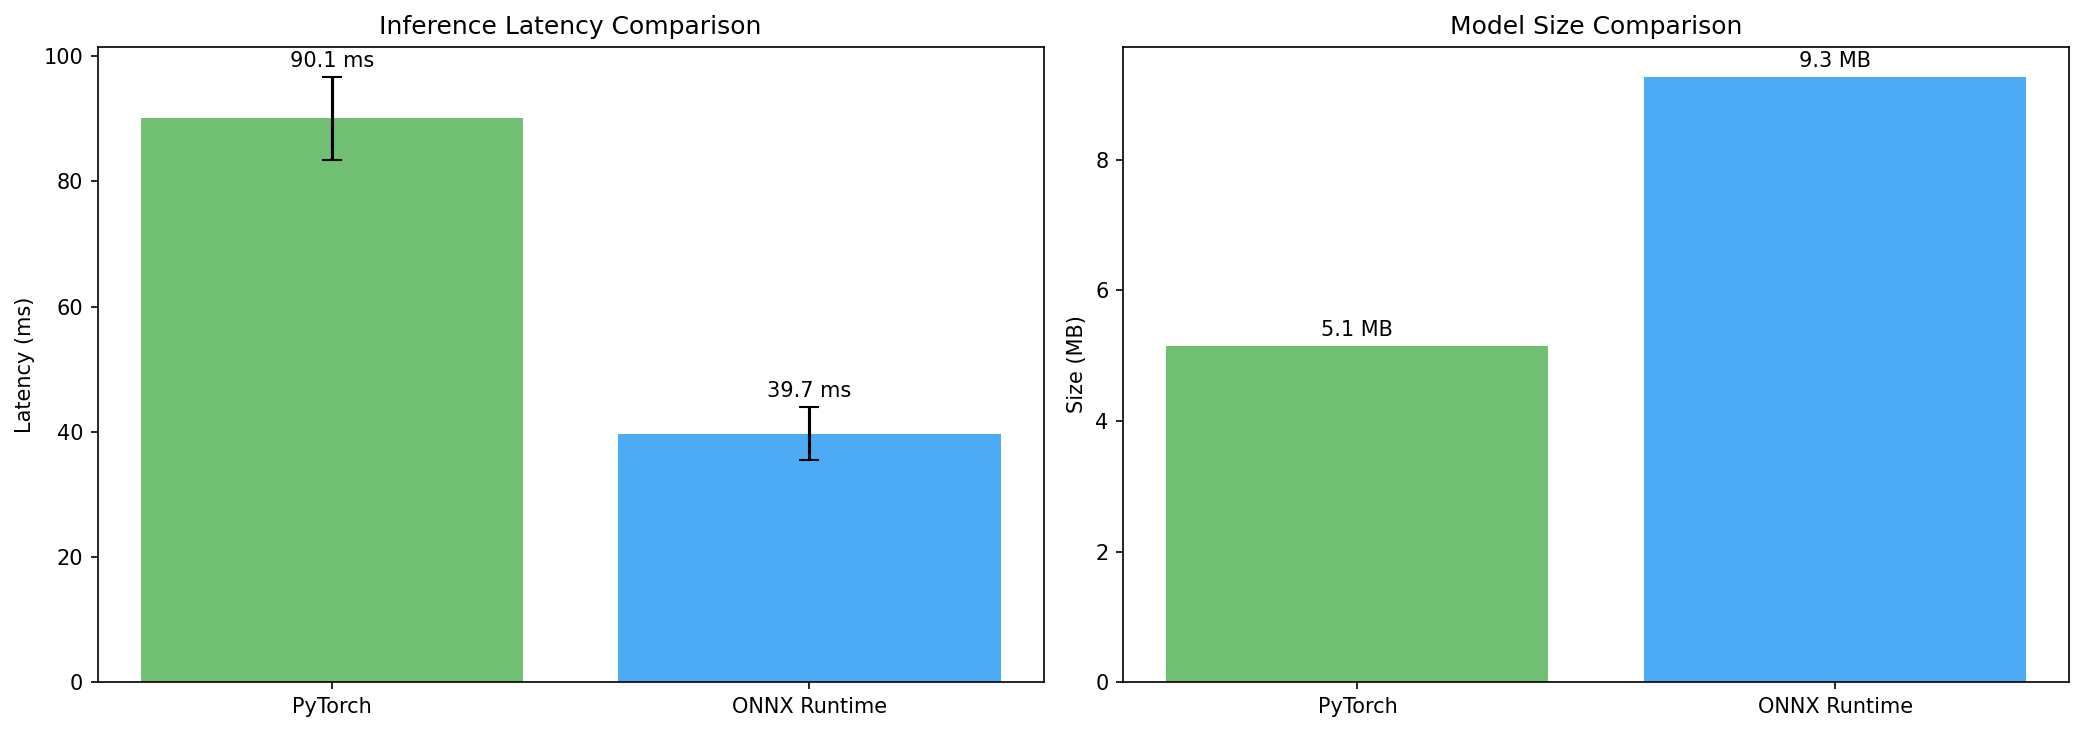

Saved benchmark plot: /home/appuser/Hailo-Training/models/benchmark_comparison.png

ONNX model ready for Hailo parsing: /home/appuser/Hailo-Training/models/best_simplified.onnx
Next step: Run 03_Hailo_Parsing_and_Quantization.ipynb


In [15]:
# Visualize benchmark (robust to inline backend issues)
from IPython.display import Image as IPyImage, display
plt.switch_backend("Agg")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency comparison
backends = ["PyTorch", "ONNX Runtime"]
means = [pt_mean, ort_mean]
stds = [pt_std, ort_std]
bars = axes[0].bar(backends, means, yerr=stds, capsize=5,
                   color=["#4CAF50", "#2196F3"], alpha=0.8)
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Inference Latency Comparison")
axes[0].bar_label(bars, fmt="%.1f ms", padding=3)

# Model size comparison
sizes = [pt_size_mb, simp_size_mb]
bars2 = axes[1].bar(backends, sizes, color=["#4CAF50", "#2196F3"], alpha=0.8)
axes[1].set_ylabel("Size (MB)")
axes[1].set_title("Model Size Comparison")
axes[1].bar_label(bars2, fmt="%.1f MB", padding=3)

plt.tight_layout()
plot_path = MODELS_DIR / "benchmark_comparison.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
display(IPyImage(filename=str(plot_path)))
print(f"Saved benchmark plot: {plot_path}")

print(f"\nONNX model ready for Hailo parsing: {simplified_path}")
print(f"Next step: Run 03_Hailo_Parsing_and_Quantization.ipynb")